In [1]:
#Import packages
import pandas as pd
import numpy as np
import math
import os
from astropy.io import fits
import healpy as hp
from matplotlib import pyplot as plt

data_directory = "/mnt/lustre/scratch/nlsas/home/csic/eoy/ioj/CMBFeatureNet/data/"
os.chdir(data_directory)
print("Current working directory:", os.getcwd())

Current working directory: /mnt/lustre/scratch/nlsas/home/csic/eoy/ioj/CMBFeatureNet/data


In [2]:
from CMBFeatureNet import read_map
test_path = "./simulated_maps/"
map_temp_data_feature = read_map(test_path + 'tests_NSIDE128/cmb_map_feature_0.fits')
map_temp_data_lcdm = read_map(test_path + 'tests_NSIDE128/cmb_map_0.fits')

Filename: ./simulated_maps/tests_NSIDE128/cmb_map_feature_0.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       4   ()      
  1  xtension      1 BinTableHDU     18   192R x 1C   [1024D]   
ColDefs(
    name = 'T'; format = '1024D'
)
Filename: ./simulated_maps/tests_NSIDE128/cmb_map_0.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       4   ()      
  1  xtension      1 BinTableHDU     18   192R x 1C   [1024D]   
ColDefs(
    name = 'T'; format = '1024D'
)


NSIDE: 128


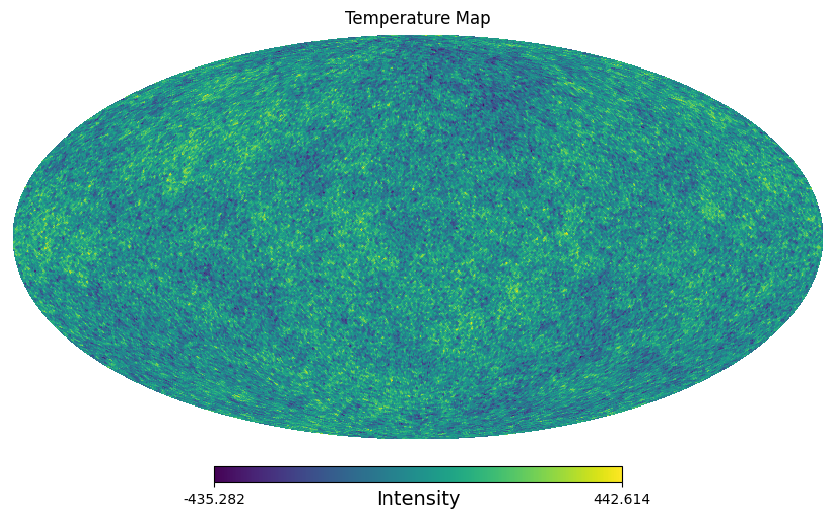

In [3]:
#Visualize the map
nside = hp.npix2nside(len(map_temp_data_feature))
print(f"NSIDE: {nside}")

#Plot
hp.mollview(map_temp_data_feature, title="Temperature Map", unit="Intensity")
plt.show()

In [4]:
#Conerting Dls to the c_ls^TT
def Cls(l,DlTT):
    ClTT = [(2*math.pi)/(l[i]*(l[i]+1))*DlTT[i] for i in range(len(l))]
    return ClTT

def Dls(l, ClTT):
    DlTT = [l[i]*(l[i]+1)/(2*np.pi)*ClTT[i] for i in range(len(l))]
    return DlTT

In [5]:
#Read the cmb angular power spectra
simulated_dlstt = np.loadtxt('./simulated_data/simulated_ang_power_spectra/dlstt_feature_0_NSIDE128.csv', delimiter=',')
#simulated_dlste = np.loadtxt('./simulated_data/simulated_ang_power_spectra/dlste_lcdm_0.csv', delimiter=',')
#simulated_dlsee = np.loadtxt('./simulated_data/simulated_ang_power_spectra/dlsee_lcdm_0.csv', delimiter=',')

In [6]:
# Combine maps into an input list

# Compute the power spectra
cl_tt_map_feature = hp.anafast(map_temp_data_feature, pol=True)
cl_tt_map_lcdm = hp.anafast(map_temp_data_lcdm, pol=True)

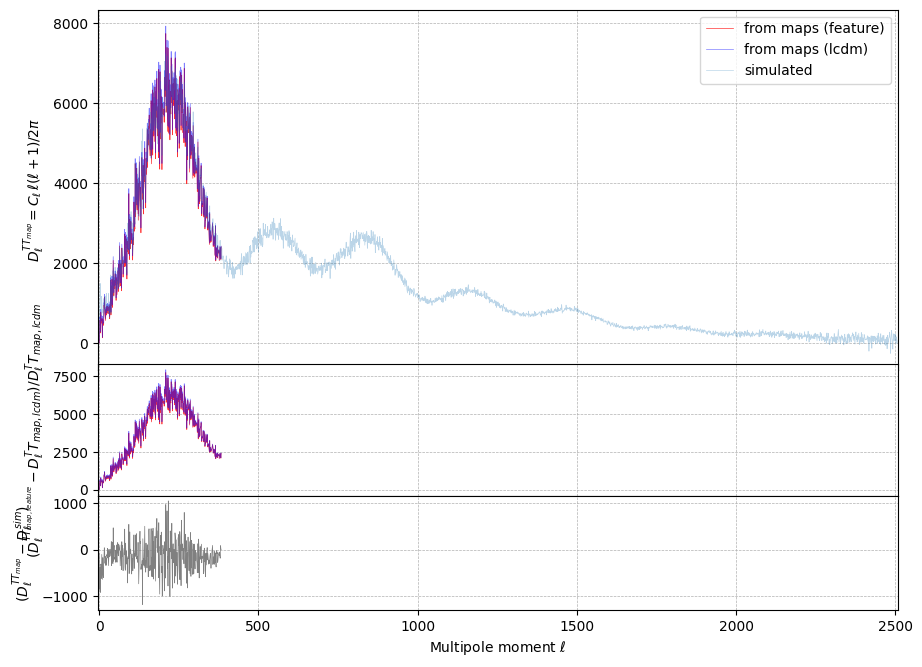

In [7]:
ell = np.arange(len(simulated_dlstt[1]))
#lmax = len(cl_tt_map)
lmax = len(cl_tt_map_lcdm)

fig = plt.figure(figsize=(10, 6))

#Upper plot (Power Spectrum)
frame1 = fig.add_axes((.1, .4, .8, .6))
frame1.plot(ell[:lmax], Dls(ell[:lmax], cl_tt_map_feature)[:lmax], 
            label='from maps (feature)', linewidth=0.5, alpha=0.8, color='red')
frame1.plot(ell[:lmax], Dls(ell[:lmax], cl_tt_map_lcdm)[:lmax], 
            label='from maps (lcdm)', linewidth=0.5, alpha=0.5, color='blue')
frame1.plot(ell, simulated_dlstt[1], 
            label='simulated', linewidth=0.5, alpha=0.3)
frame1.set_xlabel(r'Multipole moment $\ell$')
frame1.set_ylabel(r'$D_\ell^{TT_{map}}=C_\ell \, \ell(\ell+1)/2\pi$')
frame1.set_xlim(-5, len(simulated_dlstt[1]))
frame1.tick_params(axis='x', labelsize=0.1)
frame1.grid(True, which='both', linestyle='--', linewidth=0.5)
frame1.legend()

#Lower plots (Difference)
frame2 = fig.add_axes((.1, .19, .8, .22), sharex=frame1) 
diff1 = (Dls(ell[:lmax], cl_tt_map_feature) - simulated_dlstt[1][:lmax] / simulated_dlstt[1][:lmax])
diff2 = (Dls(ell[:lmax], cl_tt_map_lcdm) - simulated_dlstt[1][:lmax] / simulated_dlstt[1][:lmax])
frame2.plot(ell[:lmax], diff1, label='Percentage difference feature', linewidth=0.5, color='red', alpha=0.8)
frame2.plot(ell[:lmax], diff2, label='Percentage difference lcdm', linewidth=0.5, color='blue', alpha=0.5)
frame2.set_xlabel(r'Multipole moment $\ell$')
frame2.set_ylabel(r'$(D_\ell^{TT_{map,feature}} - D_\ell^TT_{map,lcdm}) / D_\ell^TT_{map,lcdm}$')
frame2.tick_params(axis='x', labelsize=0.1)
frame2.grid(True, which='both', linestyle='--', linewidth=0.5)

frame3 = fig.add_axes((.1, 0., .8, 0.19), sharex=frame1) 
diff = (Dls(ell[:lmax], cl_tt_map_feature) - simulated_dlstt[1][:lmax])
frame3.plot(ell[:lmax], diff, label='Percentage difference', linewidth=0.5, color='gray')
frame3.set_xlabel(r'Multipole moment $\ell$')
frame3.set_ylabel(r'$(D_\ell^{TT_{map}} - D_\ell^{sim})$')
frame3.tick_params(axis='x', labelsize=10)
frame3.grid(True, which='both', linestyle='--', linewidth=0.5)

plt.show()

In [8]:
map_temp_data_feature = read_map(test_path + 'tests_NSIDE1024/cmb_map_feature_0.fits')
map_temp_data_lcdm = read_map(test_path + 'tests_NSIDE1024/cmb_map_0.fits')

Filename: ./simulated_maps/tests_NSIDE1024/cmb_map_feature_0.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       4   ()      
  1  xtension      1 BinTableHDU     18   12288R x 1C   [1024D]   
ColDefs(
    name = 'T'; format = '1024D'
)
Filename: ./simulated_maps/tests_NSIDE1024/cmb_map_0.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       4   ()      
  1  xtension      1 BinTableHDU     18   12288R x 1C   [1024D]   
ColDefs(
    name = 'T'; format = '1024D'
)


In [9]:
#Visualize the map
nside = hp.npix2nside(len(map_temp_data_feature))
print(f"NSIDE: {nside}")

NSIDE: 1024


In [10]:
# Compute the power spectra
cl_tt_map_feature = hp.anafast(map_temp_data_feature, pol=True)
cl_tt_map_lcdm = hp.anafast(map_temp_data_lcdm, pol=True)

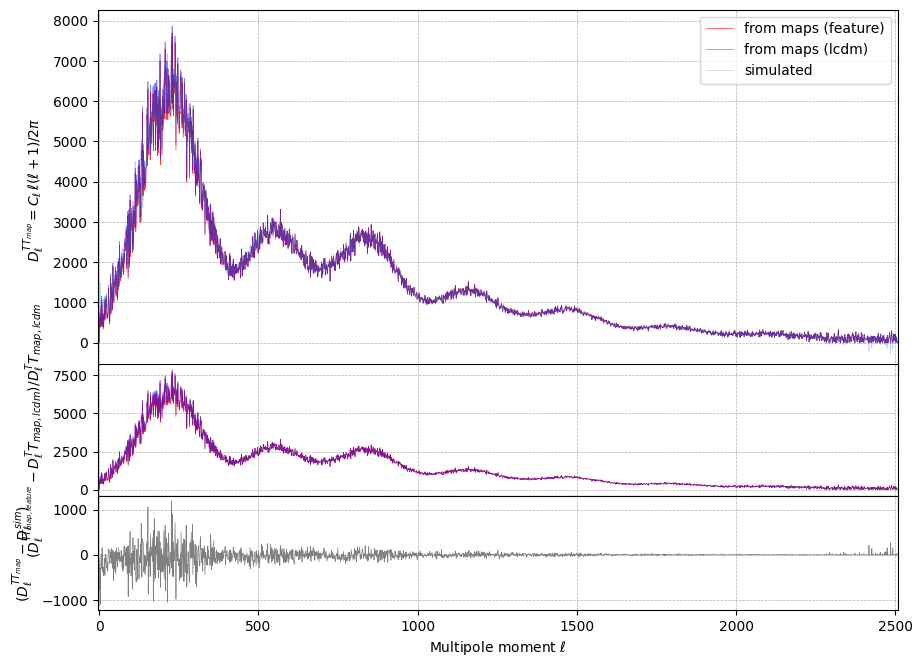

In [11]:
ell = np.arange(len(simulated_dlstt[1]))
#lmax = len(cl_tt_map)
lmax = len(cl_tt_map_lcdm)

fig = plt.figure(figsize=(10, 6))

#Upper plot (Power Spectrum)
frame1 = fig.add_axes((.1, .4, .8, .6))
frame1.plot(ell[:lmax], Dls(ell[:lmax], cl_tt_map_feature)[:lmax], 
            label='from maps (feature)', linewidth=0.5, alpha=0.8, color='red')
frame1.plot(ell[:lmax], Dls(ell[:lmax], cl_tt_map_lcdm)[:lmax], 
            label='from maps (lcdm)', linewidth=0.5, alpha=0.5, color='blue')
frame1.plot(ell, simulated_dlstt[1], 
            label='simulated', linewidth=0.5, alpha=0.3)
frame1.set_xlabel(r'Multipole moment $\ell$')
frame1.set_ylabel(r'$D_\ell^{TT_{map}}=C_\ell \, \ell(\ell+1)/2\pi$')
frame1.set_xlim(-5, len(simulated_dlstt[1]))
frame1.tick_params(axis='x', labelsize=0.1)
frame1.grid(True, which='both', linestyle='--', linewidth=0.5)
frame1.legend()

#Lower plots (Difference)
frame2 = fig.add_axes((.1, .19, .8, .22), sharex=frame1) 
diff1 = (Dls(ell[:lmax], cl_tt_map_feature) - simulated_dlstt[1][:lmax] / simulated_dlstt[1][:lmax])
diff2 = (Dls(ell[:lmax], cl_tt_map_lcdm) - simulated_dlstt[1][:lmax] / simulated_dlstt[1][:lmax])
frame2.plot(ell[:lmax], diff1, label='Percentage difference feature', linewidth=0.5, color='red', alpha=0.8)
frame2.plot(ell[:lmax], diff2, label='Percentage difference lcdm', linewidth=0.5, color='blue', alpha=0.5)
frame2.set_xlabel(r'Multipole moment $\ell$')
frame2.set_ylabel(r'$(D_\ell^{TT_{map,feature}} - D_\ell^TT_{map,lcdm}) / D_\ell^TT_{map,lcdm}$')
frame2.tick_params(axis='x', labelsize=0.1)
frame2.grid(True, which='both', linestyle='--', linewidth=0.5)

frame3 = fig.add_axes((.1, 0., .8, 0.19), sharex=frame1) 
diff = (Dls(ell[:lmax], cl_tt_map_feature) - simulated_dlstt[1][:lmax])
frame3.plot(ell[:lmax], diff, label='Percentage difference', linewidth=0.5, color='gray')
frame3.set_xlabel(r'Multipole moment $\ell$')
frame3.set_ylabel(r'$(D_\ell^{TT_{map}} - D_\ell^{sim})$')
frame3.tick_params(axis='x', labelsize=10)
frame3.grid(True, which='both', linestyle='--', linewidth=0.5)

plt.show()